---
title: "Data Cleaning"
format:
    html: 
        toc: true
        code-fold: true
        embedded-resouces: true
bibliography: ../../references.bib
---

# U.S. Exoneration Data Cleaning

## Introduction and Motivation
This section outlines the steps taken to clean and preprocess the U.S. exoneration dataset, with a specific focus on Illinois cases. The cleaning process organizes the raw data into a structured and usable format for exploratory data analysis (EDA) and subsequent analysis workflows. By the end of this phase, the dataset will be well-structured, free of inconsistencies, and ready for further exploratory data analysis and machine learning workflows.

## Initial Overview of the Dataset

### Loading the Dataset

The dataset is first loaded to inspect its structure and contents. The purpose of this step is to get an initial sense of the data types, potential missing values, and the distribution of key variables which helps inform the cleaning steps required to make the data consistent and analyzable.

In [1]:
# Import necessary Libraries:
import pandas as pd  # Used for data management, exploration, and manipulation
import numpy as np  # Used for numerical operations and array-based data processing
import seaborn as sns  # Used for data visualization, especially for missing values
import matplotlib.pyplot as plt  # Used for plotting and visualizing data
import re  # Used for handling and processing regular expressions, e.g., date cleaning

# Load exoneration dataset:
df = pd.read_csv('../../data/raw-data/US_exoneration_data.csv')
print("Initial Dataset: ")
pd.set_option('display.max_columns', None) # Enables display of every column
df.head()


Initial Dataset: 


,Last Name,First Name,Age,Race,Sex,State,County,Tags,Worst Crime Display,Sentence,Posting Date,OM Tags,F/MFE,FC,ILD,P/FA,DNA,MWID,OM,Date of Exoneration,Date of 1st Conviction,Date of Release
0,Abbitt,Joseph,31.0,Black,Male,North Carolina,Forsyth,CV;#IO;#SA,Child Sex Abuse,Life,9/1/11,NaN,NaN,NaN,NaN,NaN,DNA,MWID,NaN,9/2/09,6/22/95,9/2/09
1,Abbott,Cinque,19.0,Black,Male,Illinois,Cook,CIU;#IO;#NC;#P,Drug Possession or Sale,Probation,2/14/22,OF;#WH;#NW,NaN,NaN,NaN,P/FA,NaN,NaN,OM,2/1/22,3/25/08,3/25/08
2,Abdal,Warith Habib,43.0,Black,Male,New York,Erie,IO;#SA,Sexual Assault,20 to Life,8/29/11,OF;#WH;#NW;#WT,F/MFE,NaN,NaN,NaN,DNA,MWID,OM,9/1/99,6/6/83,9/1/99
3,Abernathy,Christopher,17.0,White,Male,Illinois,Cook,CIU;#CV;#H;#IO;#JV;#SA,Murder,Life without parole,2/13/15,OF;#WH;#NW;#INT,NaN,FC,NaN,P/FA,DNA,NaN,OM,2/11/15,1/15/87,2/11/15
4,Abney,Quentin,32.0,Black,Male,New York,New York,CV,Robbery,20 to Life,5/13/19,NaN,NaN,NaN,NaN,NaN,NaN,MWID,NaN,1/19/12,3/20/06,1/19/12


## Subsetting the Data: Illinois 

Before diving into the broader data cleaning process, I decided to narrow the scope of my research question to Illinois. This choice was intentional to focus the analysis on a specific region, ensuring that the findings are both relevant and manageable within the scope of this project. Illinois was selected because of its extensive record of exoneration cases, particularly in Cook Count (Chicago), which provides a valuable dataset for analyzing systemic issues within the criminal justice system. Chicago, in particular, has long been associated with significant racial disparities and deeply entrenched problems in policing and prosecution, making it a critical focal point for this analysis [@wttwChicagoRanks]. By focusing on Illinois, the dataset remains consistent in terms of jurisdictional laws and practices, allowing for a more accurate and concentrated exploration of patterns and trends in over-policing and wrongful convictions. This regional focus highlights the broader systemic failures of the criminal justice system while enabling a detailed examination of one of the most historically inequitable jurisdictions in terms of racial justice.

### Filtering the Dataset
To isolate Illinois cases, the dataset was filtered by the state column, retaining only rows where the value matched "Illinois." This step reduced the dataset to 548 rows, making it more manageable for analysis and visualization. Below is a preview of the filtered dataset:


In [2]:
# Filter Data for Illinois: 
df = df[df['State'] == 'Illinois']
print("Number of exonerees for Illinois subset: " , df.shape[0]) 
df.head()

Number of exonerees for Illinois subset:  548


,Last Name,First Name,Age,Race,Sex,State,County,Tags,Worst Crime Display,Sentence,Posting Date,OM Tags,F/MFE,FC,ILD,P/FA,DNA,MWID,OM,Date of Exoneration,Date of 1st Conviction,Date of Release
1,Abbott,Cinque,19.0,Black,Male,Illinois,Cook,CIU;#IO;#NC;#P,Drug Possession or Sale,Probation,2/14/22,OF;#WH;#NW,NaN,NaN,NaN,P/FA,NaN,NaN,OM,2/1/22,3/25/08,3/25/08
3,Abernathy,Christopher,17.0,White,Male,Illinois,Cook,CIU;#CV;#H;#IO;#JV;#SA,Murder,Life without parole,2/13/15,OF;#WH;#NW;#INT,NaN,FC,NaN,P/FA,DNA,NaN,OM,2/11/15,1/15/87,2/11/15
5,Abrego,Eruby,20.0,Hispanic,Male,Illinois,Cook,CDC;#H;#IO,Murder,90 years,8/25/22,OF;#WH;#NW;#WT;#INT;#PJ,NaN,FC,NaN,P/FA,NaN,MWID,OM,7/21/22,9/22/04,7/21/22
10,Adams,Demetris,22.0,Black,Male,Illinois,Cook,CIU;#IO;#NC;#P,Drug Possession or Sale,1 year,4/13/20,OF;#WH;#NW,NaN,NaN,NaN,P/FA,NaN,NaN,OM,2/11/20,9/8/04,12/26/04
15,Adams,Kenneth,22.0,Black,Male,Illinois,Cook,CDC;#H;#IO;#JI;#SA,Murder,75 years,8/29/11,PR;#OF;#WH;#NW;#KP;#WT,F/MFE,NaN,NaN,P/FA,DNA,MWID,OM,7/2/96,10/20/78,6/14/96


## Handling Missing Data

### Identifying Missing Data

Missing values are identified using `isnull()` to determine their extent and distribution across the dataset. The goal is to ensure that no critical data gaps remain unaddressed before proceeding with analysis.

In [3]:
# Managing Missing Data - Identifying which columns have a lot of missing data:
na_counts = df.isna().sum()
print(na_counts)

Last Name                   0
First Name                  0
Age                         1
Race                        0
Sex                         0
State                       0
County                      0
Tags                       15
Worst Crime Display         0
Sentence                    0
Posting Date                0
OM Tags                    70
F/MFE                     474
FC                        410
ILD                       440
P/FA                       67
DNA                       482
MWID                      442
OM                         70
Date of Exoneration         0
Date of 1st Conviction      0
Date of Release             0
dtype: int64


### Handling Missing Data

#### Rationale for Dropping Columns
The following columns were removed due to excessive missing data:

- **F/MFE, ILD, P/FA, DNA, MWID, FC:** Each of these columns had more than 50% missing values, which made them unreliable for meaningful analysis. Removing them ensures the dataset remains robust and manageable without introducing bias from imputation.

**Retaining "OM" and "OM Tags" Columns**
Initially, I removed the OM (Official Misconduct) and OM Tags columns, assuming their information would be captured in the general Tags column. However, during the exploratory data analysis (EDA), I discovered that these columns contained unique and valuable insights not present in the Tags column; as a result I retained them for further analysis.

In [4]:
# Drop columns with excessive missing values: 
df_original = df.copy()
df.drop(columns = ['F/MFE', 'ILD', 'P/FA', 'DNA', 'MWID', 'FC'], inplace = True)

#### Visualizing Missing Data

To better understand the distribution of missing values, a heatmap is generated. This visualization provides a clear overview of where missing values occur, helping to decide which columns or rows to address in subsequent steps.

##### Heatmap of Missing Values (Before Cleaning)

A heatmap is generated to visualize the extent of missing data before cleaning. Columns with a high proportion of missing values are easily identifiable, providing a clear justification for their removal.


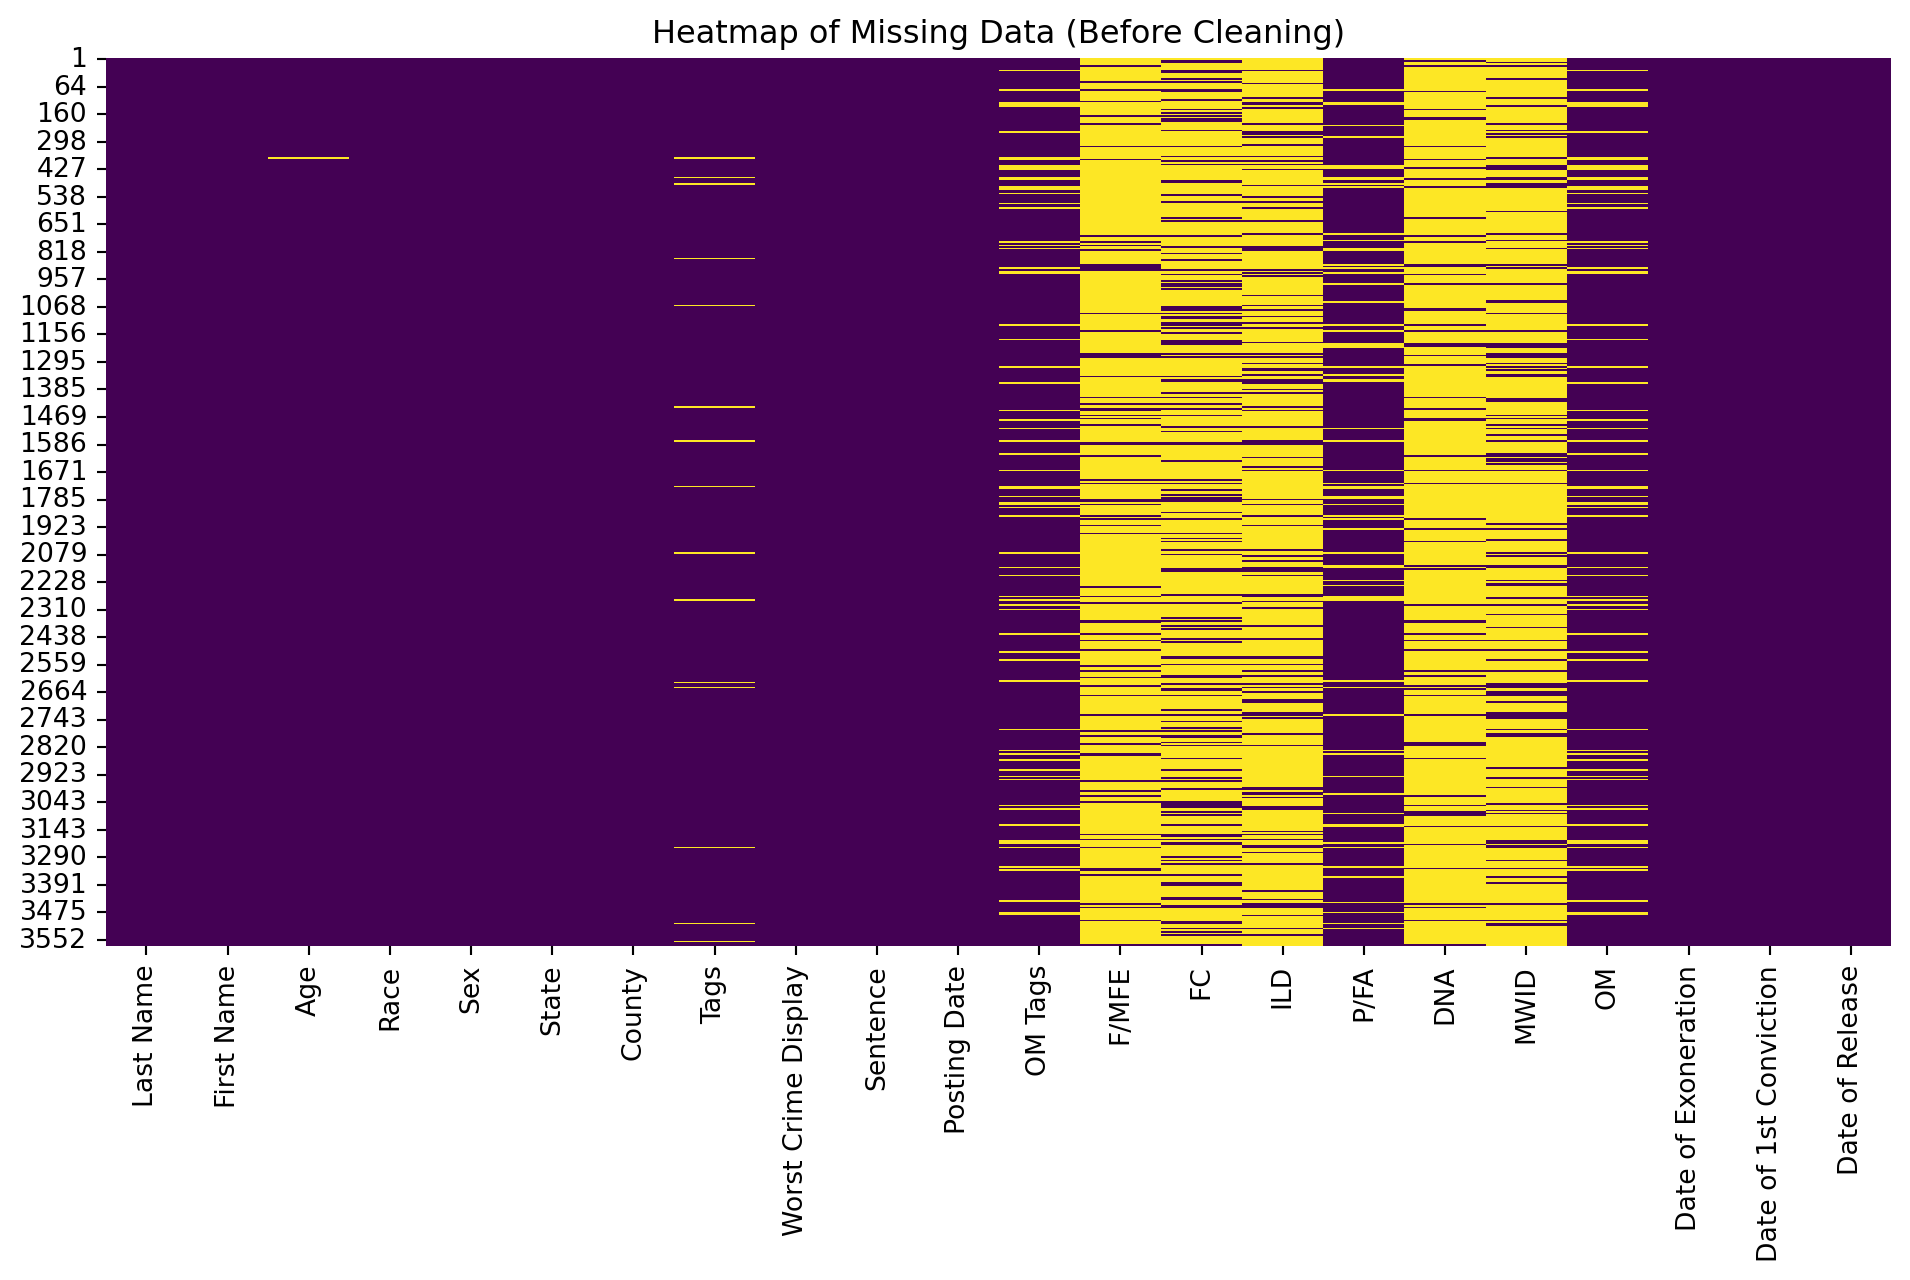

In [5]:
# Heatmap of missing data before cleaning:
plt.figure(figsize=(12, 6))
sns.heatmap(df_original.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Data (Before Cleaning)')
plt.show()


##### Heatmap of Missing Values (After Cleaning)
A second heatmap is generated after cleaning to confirm that all unnecessary columns with excessive missing values have been removed. This ensures the dataset is now complete and ready for further analysis.


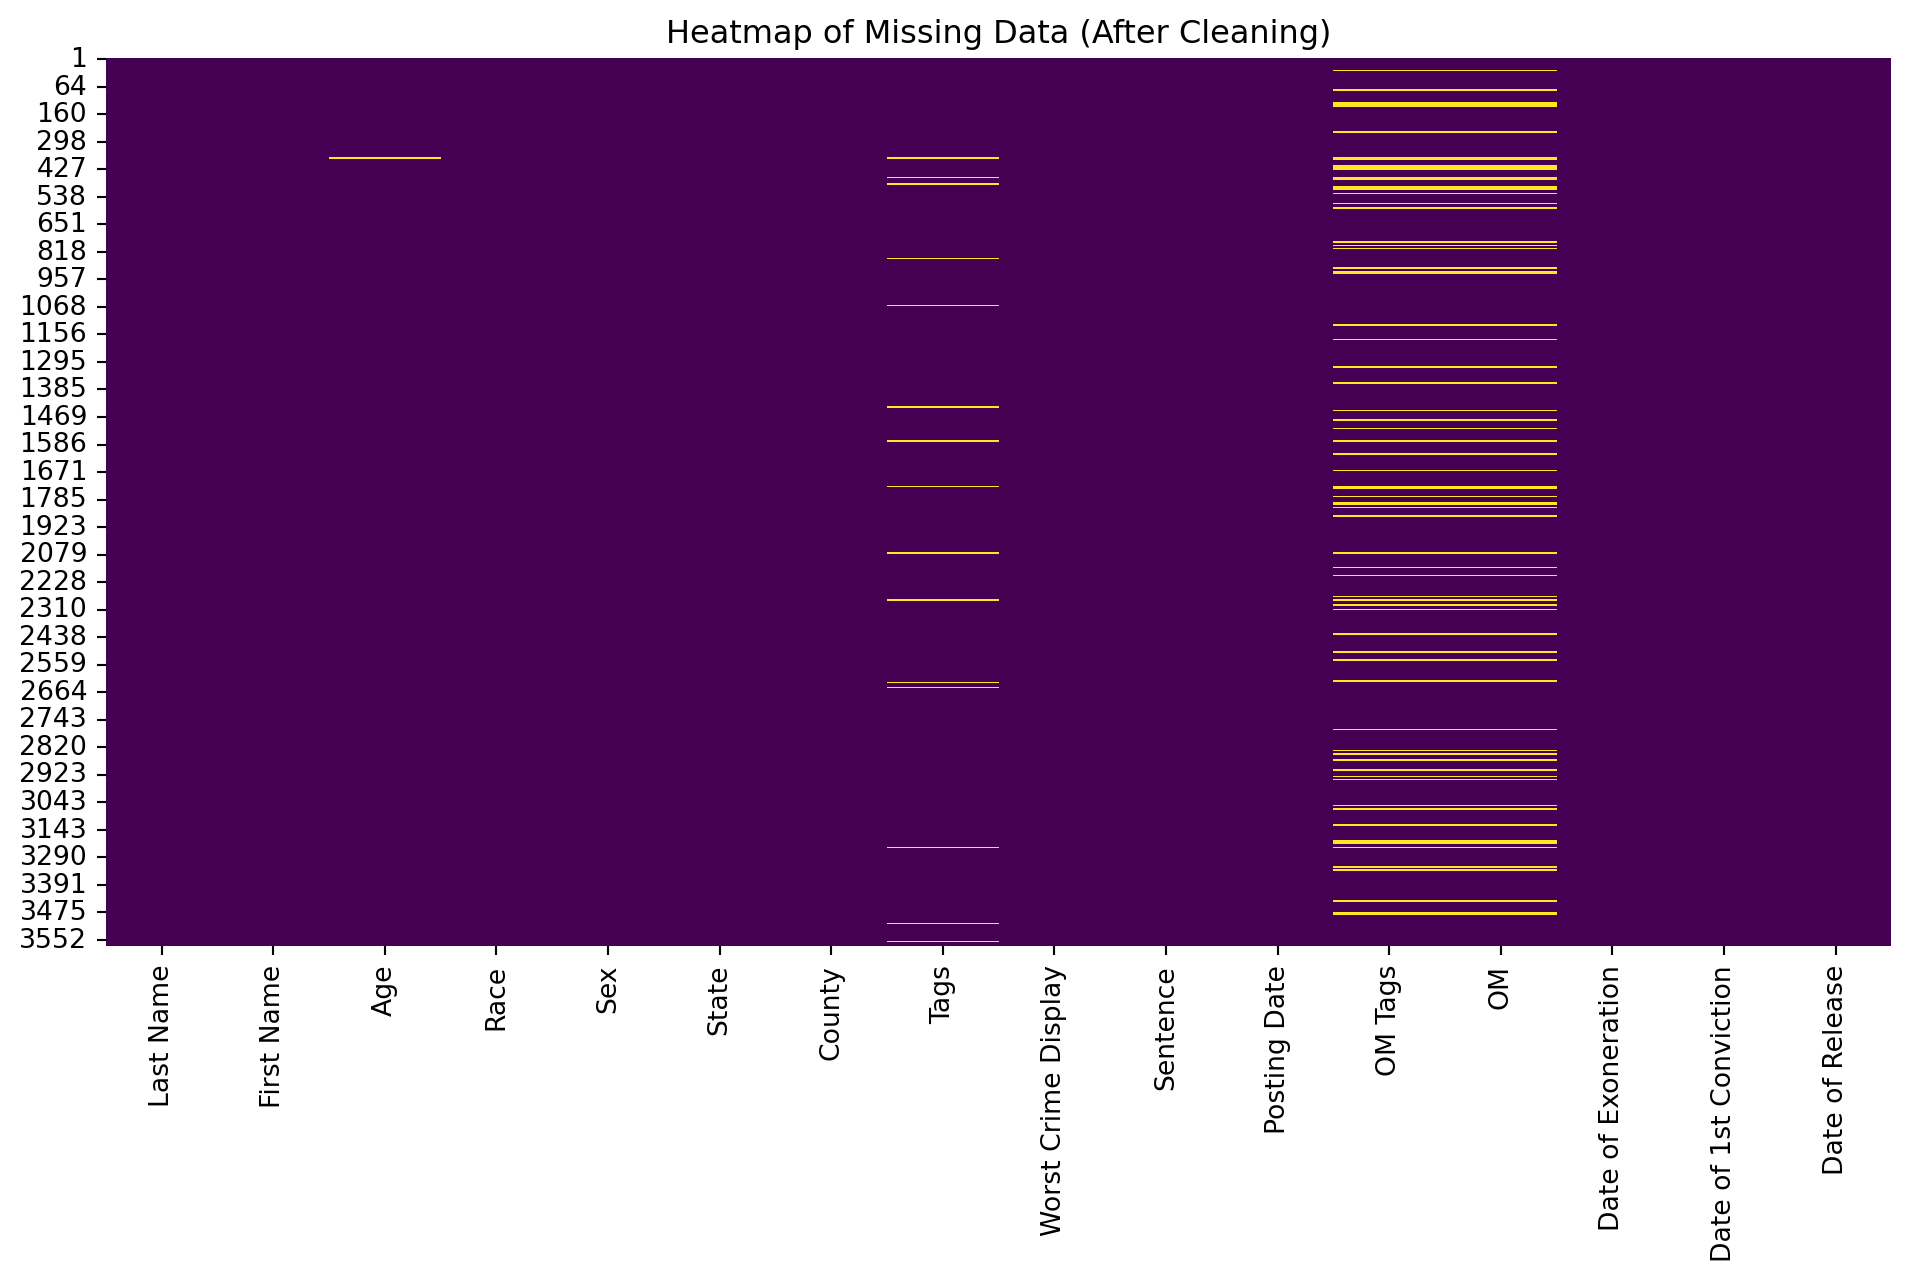

In [6]:
# Heatmap of missing data after cleaning:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Data (After Cleaning)')
plt.show()

## Column Standardization
To ensure consistency and simplify future operations, all column names were standardized by converting them to lowercase and replacing spaces with underscores (_). This transformation enhances readability, aligns with Python's naming conventions, and makes column names easier to reference in code. For example, a column originally labeled First Name is now first_name.

In [7]:
# Standardize column names by converting to lowercase and replacing spaces with '_':
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)

Index(['last_name', 'first_name', 'age', 'race', 'sex', 'state', 'county',
       'tags', 'worst_crime_display', 'sentence', 'posting_date', 'om_tags',
       'om', 'date_of_exoneration', 'date_of_1st_conviction',
       'date_of_release'],
      dtype='object')


### Text Value Standardization
Additionally, the sex column was converted to lowercase to maintain uniformity across textual data. This step ensures that values like "Male" and "male" are treated equivalently during analysis, reducing potential discrepancies caused by case sensitivity.

In [8]:
# Convert sex values to lowercase: 
df['sex'] = df['sex'].str.lower()
df['sex'].head()

1     male
3     male
5     male
10    male
15    male
Name: sex, dtype: object

## Data Type Correction and Formatting
Accurate data type formatting is essential for effective analysis. This section ensures that all variables are correctly identified as numerical, categorical, or date-time types so that they are ready for further processing.

In [9]:
# Display data types for each column:
print(df.dtypes)

last_name                  object
first_name                 object
age                       float64
race                       object
sex                        object
state                      object
county                     object
tags                       object
worst_crime_display        object
sentence                   object
posting_date               object
om_tags                    object
om                         object
date_of_exoneration        object
date_of_1st_conviction     object
date_of_release            object
dtype: object


### Data Type Correction for Textual Data
Upon reviewing the data types, it was noted that several columns, such as Last Name, First Name, Race, State, County, and Worst Crime Display, were classified as object. While this is acceptable for textual data, converting these columns to string ensures consistency and prevents potential issues when performing text-specific operations. This transformation also allows for better optimization and clarity in the data processing pipeline. The changes were necessary to standardize the dataset and ensure compatibility with downstream analysis tasks.

In [10]:
# Convert relevant columns to string type
string_columns = ['last_name', 'first_name', 'race', 'sex', 'state', 'county', 'worst_crime_display']
df[string_columns] = df[string_columns].astype('string')

# Check updated data types
print(df.dtypes)

last_name                 string[python]
first_name                string[python]
age                              float64
race                      string[python]
sex                       string[python]
state                     string[python]
county                    string[python]
tags                              object
worst_crime_display       string[python]
sentence                          object
posting_date                      object
om_tags                           object
om                                object
date_of_exoneration               object
date_of_1st_conviction            object
date_of_release                   object
dtype: object


### Date-Time Conversion
All date columns (`posting_date`, `date_of_exoneration`, `date_of_1st_conviction`, `date_of_release`) are converted to `datetime` format. This transformation ensures consistency and allows for easier time-based calculations, such as measuring the time between conviction and exoneration.


In [11]:
# Convert date columns into datetime format:
for col in ['posting_date', 'date_of_exoneration', 'date_of_1st_conviction', 'date_of_release']:
    # Convert with explicit format (MM/DD/YY):
    df[col] = pd.to_datetime(df[col], format='%m/%d/%y', errors='coerce')

print(df[['posting_date', 'date_of_exoneration', 'date_of_1st_conviction', 'date_of_release']].head())

   posting_date date_of_exoneration date_of_1st_conviction date_of_release
1    2022-02-14          2022-02-01             2008-03-25      2008-03-25
3    2015-02-13          2015-02-11             1987-01-15      2015-02-11
5    2022-08-25          2022-07-21             2004-09-22      2022-07-21
10   2020-04-13          2020-02-11             2004-09-08      2004-12-26
15   2011-08-29          1996-07-02             1978-10-20      1996-06-14


In [12]:
# Verify updated data types:
print(df.dtypes)

last_name                 string[python]
first_name                string[python]
age                              float64
race                      string[python]
sex                       string[python]
state                     string[python]
county                    string[python]
tags                              object
worst_crime_display       string[python]
sentence                          object
posting_date              datetime64[ns]
om_tags                           object
om                                object
date_of_exoneration       datetime64[ns]
date_of_1st_conviction    datetime64[ns]
date_of_release           datetime64[ns]
dtype: object


### Standardizing the `sentence` Column
The `sentence` column contains textual descriptions of sentencing outcomes, including terms like "Life without parole," "Death," or a specified number of years. To facilitate analysis, this column is transformed into a numerical format (`sentence_in_years`) by converting life sentences and probation to placeholder values and handling ranges or mixed units (e.g., years and months).


In [13]:
# Print unique sentencing values for a better idea on how to best clean column: 
unique_sentences = df['sentence'].unique()
print(unique_sentences)

['Probation' 'Life without parole' '90 years' '1 year' '75 years'
 '30 years' '55 years' '2 years' '3 years' '6 years' '45 years'
 '1 year and 6 months' '50 years' '60 years' 'Life' '80 years' '18 years'
 '4 years' '85 years' '20 years' '35 years' '2 years and 6 months'
 '82 years' '12 years' 'Not sentenced' '22 years' '32 years' 'Death'
 '5 years' '40 years' '25 years' '26 years' '4 years and 6 months'
 '9 years' '48 years' '30 days' '84 years' '3 months and 25 days'
 '2 years and 2 months' '3 months' '44 years' '6 months' '25 to 50 years'
 '29 years' '23 years' '31 years' '11 years' '8 years' '24 years'
 '3 years and four months' '42 years' '3 years and 6 months' '65 years'
 '76 years' '15 years' '50 to Life' '86 years' '70 years' '28 years'
 '13 years' '47 years' '36 years' '18 months' '1 year and 4 months'
 '8 years and 6 months' '6 years and 6 months' '58 years' '95 years'
 '7 years' '34 years' '62 years' '27 years' '69 years' '57 years'
 '50 to 100 years' '4 months' '4 years and 

##### Transforming the `sentence` Column
The `sentence` column is cleaned to convert textual descriptions into numerical values:
1. Probation and Not Sentenced are set to `0`.
2. Life sentences and the death penalty are represented as `100` for placeholder analysis.
3. Ranges (e.g., "25 to 50 years") are averaged to a single value.
4. Years and months are combined into total years for uniformity.

This standardization facilitates meaningful comparisons and quantitative analysis of sentencing patterns.


In [14]:
def clean_sentence(value):
    """ Cleans the 'sentence' column values to numeric years for numerical EDA 
    - Probation is represented as 0.
    - 'Not sentenced' is converted to np.nan.
    - 'Life' and 'Death' sentences are represented as 100 (placeholder).
    - Years and months are converted to a numeric value in years. """

    if value == 'Probation':
        return 0
    elif value == 'Not sentenced':
        return np.nan  # NaN for not sentenced
    elif 'Life' in value or value == 'Death':
        return 100  # Placeholder for life sentences or death penalty
    elif 'year' in value or 'month' in value:

        # Handles ranges like '25 to 50 years'
        if 'to' in value:
            years = [int(num) for num in re.findall(r'\d+', value)]
            return sum(years) / len(years)  # Average the range 
        
        # Handle "X years and Y months"
        elif 'and' in value:
            numbers = [float(num) for num in re.findall(r'\d+', value)]
            if len(numbers) == 2:  # Both years and months are present
                years, months = numbers
                return years + (months / 12)  # Convert months to years
            elif len(numbers) == 1:  # Only one number is present
                return numbers[0]  # Treat it as years
            
        # Handle only months or only years
        elif 'months' in value:
            months = int(re.search(r'\d+', value).group())
            return months / 12  # Convert months to years
        else:  # Only years
            return int(re.search(r'\d+', value).group())
    else:
        return np.nan  # Anything unexpected as None
    
df['sentence_in_years'] = df['sentence'].apply(clean_sentence)

# Check results
df[['sentence', 'sentence_in_years']].head(10)

,sentence,sentence_in_years
1,Probation,0.0
3,Life without parole,100.0
5,90 years,90.0
10,1 year,1.0
15,75 years,75.0
21,Probation,0.0
22,Probation,0.0
24,30 years,30.0
25,55 years,55.0
45,1 year,1.0


In [15]:
# Check updated data types
print(df.dtypes)

last_name                 string[python]
first_name                string[python]
age                              float64
race                      string[python]
sex                       string[python]
state                     string[python]
county                    string[python]
tags                              object
worst_crime_display       string[python]
sentence                          object
posting_date              datetime64[ns]
om_tags                           object
om                                object
date_of_exoneration       datetime64[ns]
date_of_1st_conviction    datetime64[ns]
date_of_release           datetime64[ns]
sentence_in_years                float64
dtype: object


After transforming the sentence column into a numerical format, the new column, `sentence_in_years` is now represented as a float64, which aligns with the desired structure for numerical analysis. This conversion allows for quantitative exploration of the sentencing data, such as aggregations and comparisons, during later stages of analysis. The original sentence column is retained for reference purposes, as it preserves the detailed textual descriptions that might be useful for contextual insights. The `tags`, `OM`, and `OM_tags` columns will be addressed later, so for now the datatype may remain as an object.

## Cleaning the `tags` and `OM-tags` Columns  
The `tags` and `OM-tags` columns contain important categorical information about each exoneration case. To make this data more useful for analysis, both columns were transformed into multiple binary columns, where each tag indicates the presence (`1`) or absence (`0`) of a specific feature. Additionally, a `tag_sum` column was created to capture the total number of tags associated with each case, providing a summary metric.

The cleaning process involved the following steps:

1. **Removing Unnecessary Characters**:  
   Unwanted characters such as `#` were removed, and delimiters were standardized to ensure consistency in the data.

2. **Splitting Tags**:  
   The `tags` and `OM-tags` columns were split into individual values to facilitate binary encoding.

3. **Renaming Binary Columns**:  
   Each binary column was renamed using clear and descriptive labels by mapping the original tags to their definitions. This mapping process translated short tag codes into their full meanings, improving interpretability. For reference, the definitions of the tags are based on the descriptions provided by the National Registry of Exonerations [@university_of_california_irvine_newkirk_center_for_science__society_exoneration].

4. **Adding a `tag_sum` Column**:  
   A new column was created to calculate the total number of tags for each case, enabling easier analysis of case complexity.

This transformation ensures the data is well-structured and ready for exploratory analysis, providing detailed insights into the systemic patterns in exoneration cases.

In [16]:
# Clean 'tags' column:
df['tags'] = df['tags'].str.replace('#', '', regex=False).str.replace(";", ",")
df['OM-tags'] = df['om_tags'].str.replace('#', '', regex=False).str.replace(";", ",")

# Define the mapping for tags:
tag_mapping = {
    "A": "arson",
    "BM": "bitemark",
    "CDC": "co_defendant_confessed",
    "CIU": "conviction_integrity_unit",
    "CSH": "child_sex_abuse_hysteria_case",
    "CV": "child_victim",
    "F": "female_exoneree",
    "FED": "federal_case",
    "H": "homicide",
    "IO": "innocence_organization",
    "JI": "jailhouse_informant",
    "JV": "juvenile_defendant",
    "M": "misdemeanor",
    "NC": "no_crime_case",
    "P": "guilty_plea_case",
    "PH": "posthumous_exoneration",
    "SA": "sexual_assault",
    "SBS": "shaken_baby_syndrome_case",
    "PR": "prosecutor_misconduct",
    "OF": "police_officer_misconduct",
    "FA": "forensic_analyst_misconduct",
    "CW": "child_welfare_worker_misconduct",
    "WH": "withheld_exculpatory_evidence",
    "NW": "misconduct_that_is_not_withholding_evidence",
    "KP": "knowingly_permitting_perjury",
    "WT": "witness_tampering_or_misconduct_interrogating_co_defendant",
    "INT": "misconduct_in_interrogation_of_exoneree",
    "PJ": "perjury_by_official",
    "PL": "prosecutor_lied_in_court"
}

# Split 'tags' and 'OM-tags' into lists:
df['tags'] = df['tags'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
df['OM-tags'] = df['OM-tags'].apply(lambda x: x.split(',') if isinstance(x, str) else x)

# Create binary columns for tags from both 'tags' and 'OM-tags':
for tag in tag_mapping.keys():
    # Check if the tag exists in 'tags' or 'OM-tags':
    df[tag] = df.apply(
        lambda row: 1 if (isinstance(row['tags'], list) and tag in row['tags']) or 
                          (isinstance(row['OM-tags'], list) and tag in row['OM-tags']) else 0,
        axis=1
    )

# Rename the binary columns using the tag_mapping dictionary:
df.rename(columns=tag_mapping, inplace=True)

# Create `tag_sum` column to count the total number of tags for each exoneree:
df['tag_sum'] = df[list(tag_mapping.values())].sum(axis=1)

# Drop the original 'tags' and 'OM-tags' columns:
df.drop(columns=['tags', 'om_tags', 'OM-tags'], inplace=True)

df.head()  


,last_name,first_name,age,race,sex,state,county,worst_crime_display,sentence,posting_date,om,date_of_exoneration,date_of_1st_conviction,date_of_release,sentence_in_years,arson,bitemark,co_defendant_confessed,conviction_integrity_unit,child_sex_abuse_hysteria_case,child_victim,female_exoneree,federal_case,homicide,innocence_organization,jailhouse_informant,juvenile_defendant,misdemeanor,no_crime_case,guilty_plea_case,posthumous_exoneration,sexual_assault,shaken_baby_syndrome_case,prosecutor_misconduct,police_officer_misconduct,forensic_analyst_misconduct,child_welfare_worker_misconduct,withheld_exculpatory_evidence,misconduct_that_is_not_withholding_evidence,knowingly_permitting_perjury,witness_tampering_or_misconduct_interrogating_co_defendant,misconduct_in_interrogation_of_exoneree,perjury_by_official,prosecutor_lied_in_court,tag_sum
1,Abbott,Cinque,19.0,Black,male,Illinois,Cook,Drug Possession or Sale,Probation,2022-02-14,OM,2022-02-01,2008-03-25,2008-03-25,0.0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,7
3,Abernathy,Christopher,17.0,White,male,Illinois,Cook,Murder,Life without parole,2015-02-13,OM,2015-02-11,1987-01-15,2015-02-11,100.0,0,0,0,1,0,1,0,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,10
5,Abrego,Eruby,20.0,Hispanic,male,Illinois,Cook,Murder,90 years,2022-08-25,OM,2022-07-21,2004-09-22,2022-07-21,90.0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,1,1,1,0,9
10,Adams,Demetris,22.0,Black,male,Illinois,Cook,Drug Possession or Sale,1 year,2020-04-13,OM,2020-02-11,2004-09-08,2004-12-26,1.0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,7
15,Adams,Kenneth,22.0,Black,male,Illinois,Cook,Murder,75 years,2011-08-29,OM,1996-07-02,1978-10-20,1996-06-14,75.0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,1,0,1,1,0,0,1,1,1,1,0,0,0,11


In [17]:
# Convert 'OM' column to binary (1 if "OM" is present, 0 otherwise)
df['om'] = df['om'].apply(lambda x: 1 if str(x).strip().upper() == "OM" else 0)

# Verify the transformation
print(df['om'].value_counts())


om
1    478
0     70
Name: count, dtype: int64


## Merge with Geocoded Counties 

The geocoded Illinois counties from *Data Collection* were merged into the main dataset:

1. **Load and Standardize Data**: Geocoded data was loaded, and column names were standardized to lowercase for consistency.  

2. **Filter Relevant Counties**: The geocoded data was filtered to include only counties present in the main dataset.  

3. **Merge Data**: Using a left join on `county` and `state`, geographic details (`geocode_address`, `latitude`, and `longitude`) were added to the dataset.  

In [18]:
# Read the geocoded population data from Data Collection
geocode_unique = pd.read_csv("../../data/raw-data/geocoded_population_counties.csv")

# Rename columns to lowercase for consistency
geocode_unique.rename(columns={"County": "county", "State": "state"}, inplace=True)

# Filter geocode_unique to only include counties present in df
geocode_unique_filtered = geocode_unique[
    geocode_unique[['county', 'state']].apply(tuple, axis=1).isin(df[['county', 'state']].apply(tuple, axis=1))
]

# Merge the filtered geocoding data into df
df = df.merge(geocode_unique_filtered, on=['county', 'state'], how='left')

# Display the relevant columns to verify the merge
print(df[['state', 'county', 'geocode_address', 'latitude', 'longitude']].head())

      state county                       geocode_address   latitude  longitude
0  Illinois   Cook  Cook County, Illinois, United States  41.819738 -87.756525
1  Illinois   Cook  Cook County, Illinois, United States  41.819738 -87.756525
2  Illinois   Cook  Cook County, Illinois, United States  41.819738 -87.756525
3  Illinois   Cook  Cook County, Illinois, United States  41.819738 -87.756525
4  Illinois   Cook  Cook County, Illinois, United States  41.819738 -87.756525


## Calculating Years Lost  

To quantify the `years_lost` due to wrongful conviction, this step calculates the difference in years between an individual's `date_of_1st_conviction` and their `date_of_release`.

In [19]:
# Calculate "years lost" as the difference in years between release and conviction:
df['years_lost'] = (df['date_of_release'] - df['date_of_1st_conviction']).dt.days / 365.25 # Dividing by 365.25 accounts for leap years

# Round the years lost to 2 decimal places:
df['years_lost'] = df['years_lost'].round(2)

# Updated DataFrame:
print(df[['date_of_1st_conviction', 'date_of_release', 'years_lost']])

    date_of_1st_conviction date_of_release  years_lost
0               2008-03-25      2008-03-25        0.00
1               1987-01-15      2015-02-11       28.07
2               2004-09-22      2022-07-21       17.83
3               2004-09-08      2004-12-26        0.30
4               1978-10-20      1996-06-14       17.65
..                     ...             ...         ...
543             2005-04-13      2005-04-13        0.00
544             2005-01-11      2006-07-12        1.50
545             2005-04-11      2006-12-07        1.66
546             2003-04-21      2005-03-10        1.89
547             1994-09-20      2005-01-31       10.37

[548 rows x 3 columns]


## Column Reorganization  

To improve readability and logical flow, the following changes were made to the column order:  

1. **Align Sentencing Data**:  
   The `sentence_in_years` column was moved to appear immediately after `sentence`, ensuring that the cleaned numerical representation of sentencing data is logically aligned with its original textual description.  

2. **Reorganize Release and Years Lost**:  
   The `years_lost` column was moved to appear immediately after `date_of_release`, facilitating easier comparison of release dates and the calculated time lost due to wrongful incarceration.  

3. **Group Geographic Data**:  
   The `latitude` and `longitude` columns were moved to follow the `county` column, grouping geographic information together.


In [20]:
# Reordering columns:
columns = list(df.columns)  

#Aligning sentencing data:  
columns.insert(columns.index('sentence') + 1, columns.pop(columns.index('sentence_in_years')))  # Move 'sentence_in_years'

#Reorganizing release and years lost
columns.insert(columns.index('date_of_release') +1, columns.pop(columns.index('years_lost'))) #Move 'years_lost' 

# Move 'latitude' and 'longitude' after 'county'
columns.insert(columns.index('county') + 1, columns.pop(columns.index('latitude')))
columns.insert(columns.index('county') + 2, columns.pop(columns.index('longitude')))

df = df[columns]  # Reorder DataFrame

df.head(10)

,last_name,first_name,age,race,sex,state,county,latitude,longitude,worst_crime_display,sentence,sentence_in_years,posting_date,om,date_of_exoneration,date_of_1st_conviction,date_of_release,years_lost,arson,bitemark,co_defendant_confessed,conviction_integrity_unit,child_sex_abuse_hysteria_case,child_victim,female_exoneree,federal_case,homicide,innocence_organization,jailhouse_informant,juvenile_defendant,misdemeanor,no_crime_case,guilty_plea_case,posthumous_exoneration,sexual_assault,shaken_baby_syndrome_case,prosecutor_misconduct,police_officer_misconduct,forensic_analyst_misconduct,child_welfare_worker_misconduct,withheld_exculpatory_evidence,misconduct_that_is_not_withholding_evidence,knowingly_permitting_perjury,witness_tampering_or_misconduct_interrogating_co_defendant,misconduct_in_interrogation_of_exoneree,perjury_by_official,prosecutor_lied_in_court,tag_sum,geocode_address
0,Abbott,Cinque,19.0,Black,male,Illinois,Cook,41.819738,-87.756525,Drug Possession or Sale,Probation,0.0,2022-02-14,1,2022-02-01,2008-03-25,2008-03-25,0.00,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,7,"Cook County, Illinois, United States"
1,Abernathy,Christopher,17.0,White,male,Illinois,Cook,41.819738,-87.756525,Murder,Life without parole,100.0,2015-02-13,1,2015-02-11,1987-01-15,2015-02-11,28.07,0,0,0,1,0,1,0,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,10,"Cook County, Illinois, United States"
2,Abrego,Eruby,20.0,Hispanic,male,Illinois,Cook,41.819738,-87.756525,Murder,90 years,90.0,2022-08-25,1,2022-07-21,2004-09-22,2022-07-21,17.83,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,1,1,1,0,9,"Cook County, Illinois, United States"
3,Adams,Demetris,22.0,Black,male,Illinois,Cook,41.819738,-87.756525,Drug Possession or Sale,1 year,1.0,2020-04-13,1,2020-02-11,2004-09-08,2004-12-26,0.30,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,7,"Cook County, Illinois, United States"
4,Adams,Kenneth,22.0,Black,male,Illinois,Cook,41.819738,-87.756525,Murder,75 years,75.0,2011-08-29,1,1996-07-02,1978-10-20,1996-06-14,17.65,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,1,0,1,1,0,0,1,1,1,1,0,0,0,11,"Cook County, Illinois, United States"
5,Adams,Seneca,20.0,Black,male,Illinois,Cook,41.819738,-87.756525,Assault,Probation,0.0,2014-12-08,1,2006-12-19,2006-05-18,2006-05-18,0.00,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,6,"Cook County, Illinois, United States"
6,Adams,Tari,18.0,Black,male,Illinois,Cook,41.819738,-87.756525,Assault,Probation,0.0,2014-12-08,1,2006-12-19,2006-05-18,2006-05-18,0.00,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,6,"Cook County, Illinois, United States"
7,Agnew,Gregory,28.0,Black,male,Illinois,Lake,42.332738,-87.993955,Robbery,30 years,30.0,2018-01-18,0,2001-11-07,1988-06-14,2001-11-07,13.40,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"Lake County, Illinois, United States"
8,Aguirre,Omar,28.0,Hispanic,male,Illinois,Cook,41.819738,-87.756525,Murder,55 years,55.0,2011-08-29,1,2003-02-18,1999-03-09,2002-12-18,3.78,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,1,1,0,0,7,"Cook County, Illinois, United States"
9,Ali,Chauncey,37.0,Black,male,Illinois,Cook,41.819738,-87.756525,Drug Possession or Sale,1 year,1.0,2020-04-13,1,2020-02-11,2007-01-17,2007-06-27,0.44,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,7,"Cook County, Illinois, United States"


## Exporting the Cleaned Dataset

The final cleaned dataset is saved as `illinois_exoneration_data.csv`, ensuring that all preprocessing steps are reproducible, and the dataset can be used consistently across various analysis stages.


In [21]:
df.to_csv('../../data/processed-data/illinois_exoneration_data.csv', index=False)
print("Data saved to 'illinois_exoneration_data.csv'")

Data saved to 'illinois_exoneration_data.csv'


# Illinois Arrest Data Cleaning  

## Introduction and Motivation  
This section documents the steps taken to clean and preprocess the Illinois arrest dataset. Similarly to the U.S. exoneration dataset, the goal is to transform the raw data into a structured and reliable format for analysis. However, this dataset required fewer cleaning steps due to its uniform structure and consistent formatting.  

By the end of this phase, the Illinois arrest dataset will be well-prepared for exploratory data analysis (EDA) and integration into broader investigative workflows.

## Initial Overview of the Dataset
The dataset is first loaded to inspect its structure and contents. 

In [22]:
# Load exoneration dataset:
arrest_data = pd.read_csv('../../data/raw-data/illinois_arrest_explorer_data.csv')
print("Initial Dataset: ")
pd.set_option('display.max_columns', None) # Enables display of every column
arrest_data.head()

Initial Dataset: 


,Year,race,county_Adams,county_Alexander,county_Bond,county_Boone,county_Brown,county_Bureau,county_Calhoun,county_Carroll,county_Cass,county_Champaign,county_Christian,county_Clark,county_Clay,county_Clinton,county_Coles,county_Cook Chicago,county_Cook County Suburbs,county_Crawford,county_Cumberland,county_Dekalb,county_Dewitt,county_Douglas,county_Dupage,county_Edgar,county_Edwards,county_Effingham,county_Fayette,county_Ford,county_Franklin,county_Fulton,county_Gallatin,county_Greene,county_Grundy,county_Hamilton,county_Hancock,county_Hardin,county_Henderson,county_Henry,county_Iroquois,county_Jackson,county_Jasper,county_Jefferson,county_Jersey,county_Jo Daviess,county_Johnson,county_Kane,county_Kankakee,county_Kendall,county_Knox,county_Lake,county_Lasalle,county_Lawrence,county_Lee,county_Livingston,county_Logan,county_Macon,county_Macoupin,county_Madison,county_Marion,county_Marshall,county_Mason,county_Massac,county_Mcdonough,county_Mchenry,county_Mclean,county_Menard,county_Mercer,county_Monroe,county_Montgomery,county_Morgan,county_Moultrie,county_Non County Agencies,county_Ogle,county_Peoria,county_Perry,county_Piatt,county_Pike,county_Pope,county_Pulaski,county_Putnam,county_Randolph,county_Richland,county_Rock Island,county_Saline,county_Sangamon,county_Schuyler,county_Scott,county_Shelby,county_St. Clair,county_Stark,county_Stephenson,county_Tazewell,county_Union,county_Vermilion,county_Wabash,county_Warren,county_Washington,county_Wayne,county_White,county_Whiteside,county_Will,county_Williamson,county_Winnebago,county_Woodford
0,2001,African American,226,147,25,18,18,48,6,12,1,2059,16,6,1,22,130,86781,26301,6,1,342,11,18,2265,1,1,108,6,1,6,25,1,1,52,1,1,1,6,92,250,580,1,246,6,16,16,2804,1669,122,314,5712,184,6,86,180,71,1104,34,1567,146,6,1,91,105,213,905,1,6,20,38,287,6,1,57,3403,60,1,13,1,153,1,81,6,1215,104,2200,6,1,1,2462,1,355,168,17,876,6,46,25,6,16,128,3000,75,2509,42
1,2001,Asian,1,1,1,1,1,1,1,1,1,49,1,1,1,1,1,722,460,1,1,15,1,1,139,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,97,1,1,1,135,1,1,1,1,1,1,1,12,1,1,1,1,6,6,16,1,1,1,1,1,1,1,1,12,1,1,1,1,1,1,1,1,1,1,17,1,1,1,6,1,1,6,1,1,1,1,1,1,1,1,14,1,28,1
2,2001,Hispanic,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,2001,Native American,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,146,30,1,1,1,1,1,17,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,16,1,1,1,10,1,1,1,1,1,1,1,6,1,1,1,1,1,1,6,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,6,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,6,1
4,2001,White,939,52,209,674,107,509,139,298,88,2334,335,264,117,229,1635,37099,36690,470,164,1740,539,181,13019,301,41,986,382,217,724,926,19,57,1014,78,206,75,134,569,585,857,87,607,575,532,198,9634,1607,1465,1160,15136,2689,412,845,1146,586,1388,523,4359,571,263,274,455,1007,3879,2285,92,410,572,749,1053,149,1,1009,3120,430,211,368,45,248,151,460,323,3117,711,3635,274,22,486,1601,59,644,1804,327,1743,324,444,265,245,668,1304,4144,631,4253,462


## Column Renaming and Consolidation  

To streamline the Illinois arrest dataset and improve clarity, the following transformations were applied:  

1. **Removing Prefixes for Simplicity**:  
   Columns with the `county_` prefix were renamed by removing the prefix and capitalizing the remaining column names. This makes the column headers cleaner and more intuitive for analysis.  

2. **Standardizing Race Terminology**:  
   The term *"African American"* in the `race` column was replaced with *"Black"* to ensure consistency with the exoneration dataset.

3. **Consolidating Cook County Data**:  
   The columns `Cook Chicago` and `Cook County Suburbs` were combined into a single `Cook` column. This consolidation simplifies the data and groups all arrest information related to Cook County into a unified metric.  

In [23]:
# Rename columns by removing 'county_' prefix:
arrest_data.columns = [col.replace('county_', '').capitalize() if col.startswith('county_') else col for col in arrest_data.columns]

# Rename "African American" to "Black" in the column names:
arrest_data['race'] = arrest_data['race'].replace('African American', 'Black')

# Combine "Cook Chicago" and "Cook County Suburbs" into a single "Cook" column:
arrest_data['Cook'] = arrest_data['Cook chicago'] + arrest_data['Cook county suburbs']

# Drop the old columns:
arrest_data.drop(columns=['Cook chicago', 'Cook county suburbs'], inplace=True)

arrest_data.head(1)

,Year,race,Adams,Alexander,Bond,Boone,Brown,Bureau,Calhoun,Carroll,Cass,Champaign,Christian,Clark,Clay,Clinton,Coles,Crawford,Cumberland,Dekalb,Dewitt,Douglas,Dupage,Edgar,Edwards,Effingham,Fayette,Ford,Franklin,Fulton,Gallatin,Greene,Grundy,Hamilton,Hancock,Hardin,Henderson,Henry,Iroquois,Jackson,Jasper,Jefferson,Jersey,Jo daviess,Johnson,Kane,Kankakee,Kendall,Knox,Lake,Lasalle,Lawrence,Lee,Livingston,Logan,Macon,Macoupin,Madison,Marion,Marshall,Mason,Massac,Mcdonough,Mchenry,Mclean,Menard,Mercer,Monroe,Montgomery,Morgan,Moultrie,Non county agencies,Ogle,Peoria,Perry,Piatt,Pike,Pope,Pulaski,Putnam,Randolph,Richland,Rock island,Saline,Sangamon,Schuyler,Scott,Shelby,St. clair,Stark,Stephenson,Tazewell,Union,Vermilion,Wabash,Warren,Washington,Wayne,White,Whiteside,Will,Williamson,Winnebago,Woodford,Cook
0,2001,Black,226,147,25,18,18,48,6,12,1,2059,16,6,1,22,130,6,1,342,11,18,2265,1,1,108,6,1,6,25,1,1,52,1,1,1,6,92,250,580,1,246,6,16,16,2804,1669,122,314,5712,184,6,86,180,71,1104,34,1567,146,6,1,91,105,213,905,1,6,20,38,287,6,1,57,3403,60,1,13,1,153,1,81,6,1215,104,2200,6,1,1,2462,1,355,168,17,876,6,46,25,6,16,128,3000,75,2509,42,113082


## Handling Placeholder Values  

During preprocessing, it was observed that the dataset contains `1`s in certain fields. To address this all `1`s in the dataset were replaced with `0`s to ensure the integrity of the analysis. This decision ensures that the data is not skewed by suspicious or placeholder values, which could misrepresent trends or introduce bias into the results.  

> **Note**: The reasoning behind the presence of these placeholder values is discussed further in the *Data Collection* section.  


In [24]:
# Replace 1s with 0s: 
arrest_data.replace(1, 0, inplace=True)

# Display the updated dataset to confirm changes:
arrest_data.head()

arrest_data.head()

,Year,race,Adams,Alexander,Bond,Boone,Brown,Bureau,Calhoun,Carroll,Cass,Champaign,Christian,Clark,Clay,Clinton,Coles,Crawford,Cumberland,Dekalb,Dewitt,Douglas,Dupage,Edgar,Edwards,Effingham,Fayette,Ford,Franklin,Fulton,Gallatin,Greene,Grundy,Hamilton,Hancock,Hardin,Henderson,Henry,Iroquois,Jackson,Jasper,Jefferson,Jersey,Jo daviess,Johnson,Kane,Kankakee,Kendall,Knox,Lake,Lasalle,Lawrence,Lee,Livingston,Logan,Macon,Macoupin,Madison,Marion,Marshall,Mason,Massac,Mcdonough,Mchenry,Mclean,Menard,Mercer,Monroe,Montgomery,Morgan,Moultrie,Non county agencies,Ogle,Peoria,Perry,Piatt,Pike,Pope,Pulaski,Putnam,Randolph,Richland,Rock island,Saline,Sangamon,Schuyler,Scott,Shelby,St. clair,Stark,Stephenson,Tazewell,Union,Vermilion,Wabash,Warren,Washington,Wayne,White,Whiteside,Will,Williamson,Winnebago,Woodford,Cook
0,2001,Black,226,147,25,18,18,48,6,12,0,2059,16,6,0,22,130,6,0,342,11,18,2265,0,0,108,6,0,6,25,0,0,52,0,0,0,6,92,250,580,0,246,6,16,16,2804,1669,122,314,5712,184,6,86,180,71,1104,34,1567,146,6,0,91,105,213,905,0,6,20,38,287,6,0,57,3403,60,0,13,0,153,0,81,6,1215,104,2200,6,0,0,2462,0,355,168,17,876,6,46,25,6,16,128,3000,75,2509,42,113082
1,2001,Asian,0,0,0,0,0,0,0,0,0,49,0,0,0,0,0,0,0,15,0,0,139,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,97,0,0,0,135,0,0,0,0,0,0,0,12,0,0,0,0,6,6,16,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,0,0,0,0,17,0,0,0,6,0,0,6,0,0,0,0,0,0,0,0,14,0,28,0,1182
2,2001,Hispanic,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2001,Native American,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,0,0,0,10,0,0,0,0,0,0,0,6,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,176
4,2001,White,939,52,209,674,107,509,139,298,88,2334,335,264,117,229,1635,470,164,1740,539,181,13019,301,41,986,382,217,724,926,19,57,1014,78,206,75,134,569,585,857,87,607,575,532,198,9634,1607,1465,1160,15136,2689,412,845,1146,586,1388,523,4359,571,263,274,455,1007,3879,2285,92,410,572,749,1053,149,0,1009,3120,430,211,368,45,248,151,460,323,3117,711,3635,274,22,486,1601,59,644,1804,327,1743,324,444,265,245,668,1304,4144,631,4253,462,73789


## Exporting Cleaned and Aggregated Datasets  

### 1. Exporting the Cleaned Dataset  

After cleaning the Illinois arrest dataset, the cleaned version was saved as a CSV file. This dataset retains the original structure, including arrest counts broken down by race, county, and year. Maintaining the year-specific information allows for detailed time-series analysis and year-over-year comparisons.  

In [25]:
arrest_data.to_csv('../../data/processed-data/arrest_data_by_year.csv', index=False)
print("Data saved to 'arrest_data_by_year.csv'")

Data saved to 'arrest_data_by_year.csv'


### 2. Aggregating Arrest Data by Race and County  

The arrest data was aggregated to simplify the analysis by summing totals across all years for each race and county. This step removes the `Year` column and groups arrests solely by race and county.  

**Steps**:  
   - Grouped the dataset by the `race` column.  
   - Summed arrest counts for each county across all years.  
   - Reset the index for a clean, tabular structure.  

In [26]:
# Aggregate totals across years for each race:
aggregated_data = arrest_data.groupby('race').sum(numeric_only=True)
aggregated_data = aggregated_data.drop(columns=['Year'])
aggregated_data = aggregated_data.reset_index()

# Preview the aggregated data:
aggregated_data.head()

,race,Adams,Alexander,Bond,Boone,Brown,Bureau,Calhoun,Carroll,Cass,Champaign,Christian,Clark,Clay,Clinton,Coles,Crawford,Cumberland,Dekalb,Dewitt,Douglas,Dupage,Edgar,Edwards,Effingham,Fayette,Ford,Franklin,Fulton,Gallatin,Greene,Grundy,Hamilton,Hancock,Hardin,Henderson,Henry,Iroquois,Jackson,Jasper,Jefferson,Jersey,Jo daviess,Johnson,Kane,Kankakee,Kendall,Knox,Lake,Lasalle,Lawrence,Lee,Livingston,Logan,Macon,Macoupin,Madison,Marion,Marshall,Mason,Massac,Mcdonough,Mchenry,Mclean,Menard,Mercer,Monroe,Montgomery,Morgan,Moultrie,Non county agencies,Ogle,Peoria,Perry,Piatt,Pike,Pope,Pulaski,Putnam,Randolph,Richland,Rock island,Saline,Sangamon,Schuyler,Scott,Shelby,St. clair,Stark,Stephenson,Tazewell,Union,Vermilion,Wabash,Warren,Washington,Wayne,White,Whiteside,Will,Williamson,Winnebago,Woodford,Cook
0,Asian,12,0,0,22,0,0,0,0,0,1186,0,0,0,6,0,0,0,301,0,0,4509,6,0,51,6,0,12,0,0,0,12,0,0,0,0,12,0,166,0,12,0,0,0,2239,30,66,0,2562,164,0,0,81,18,76,0,550,0,0,0,45,66,498,564,0,0,0,18,12,0,0,6,381,6,0,0,0,12,0,0,0,250,0,500,0,0,0,382,0,12,126,0,0,0,42,0,0,0,30,1443,36,767,46,26764
1,Black,4022,2722,533,2410,92,780,18,292,235,45547,459,187,75,877,4029,280,117,16146,594,499,59262,119,6,3293,588,275,520,627,6,110,2249,0,122,0,207,2131,3283,13120,45,5960,526,943,281,59806,27437,4308,7545,78841,7344,337,1654,4521,2353,27094,818,51485,4542,123,218,1731,4214,6581,27867,189,268,885,1275,7157,165,693,1685,79960,1901,358,519,18,3384,42,1731,213,26048,1795,63703,81,0,110,60744,24,11866,8363,399,17641,153,1024,489,91,464,2893,58968,4809,55837,2841,1772659
2,Hispanic,6,0,6,516,0,114,0,34,68,983,0,6,0,91,120,18,18,1783,84,147,13828,0,0,51,35,67,22,0,0,30,470,0,6,0,11,18,104,186,0,160,24,101,0,14151,634,264,323,10219,762,0,136,417,49,113,0,333,25,12,10,0,138,4126,1439,0,0,16,12,124,0,0,350,0,43,0,18,0,104,0,79,18,1135,0,29,12,0,0,449,0,39,192,18,0,0,142,12,0,6,436,3822,217,3522,63,144574
3,Native American,0,0,0,0,0,0,0,0,0,297,0,0,0,0,0,0,0,30,0,0,703,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,149,0,12,0,220,6,0,0,0,0,6,0,65,0,0,0,0,0,18,24,0,0,0,0,0,0,0,0,42,0,0,0,0,0,0,0,0,0,0,29,0,0,6,42,0,6,6,0,0,0,0,0,0,0,0,108,0,147,0,2351
4,White,16743,1340,3964,16580,1812,9593,1844,5530,2826,41996,10983,6714,4818,8858,23779,8663,4228,35622,7121,5676,215397,7031,1019,23978,9115,4630,22754,14545,838,5147,18813,1218,5203,1766,2653,11472,11041,16698,3124,14526,14337,7841,3325,170618,31714,27222,20553,188224,54179,8499,13856,20172,14366,30283,12071,130786,19686,4240,6970,8491,18618,101548,48554,3974,7257,10734,16631,23129,2920,751,19240,64589,12123,4323,7890,795,4457,1683,12061,6823,53728,12729,82714,2136,585,8671,49390,1442,13615,61546,6165,30772,6491,7459,5220,5146,11318,22690,97863,26871,85292,12676,1174775


In [27]:
aggregated_data.to_csv('../../data/processed-data/aggregated_arrests_2001_to_2021.csv', index=False)
print("Data saved to 'aggregated_arrests_2001_to_2021.csv'")

Data saved to 'aggregated_arrests_2001_to_2021.csv'


# Mass Incarceration Racial Geography Data Cleaning

## Introduction and Motivation  
This section documents the minimal cleaning performed on the racial geography dataset which provides population and incarceration statistics by race, making it an essential input for balancing counterfactual data for supervised learning.  

Unlike other datasets, this required minimal preprocessing due to its clean structure and consistent formatting. The primary cleaning steps involved standardizing column names for uniformity.  

By the end of this step, the dataset is ready for use in data balancing and then machine learning. 

## Initial Overview of the Dataset
The dataset is first loaded to inspect its structure and contents. 

In [28]:
representation_df = pd.read_csv('../../data/raw-data/representation_by_county_raw.csv')
print("Initial Dataset: ")
pd.set_option('display.max_columns', None) 
representation_df.head()

Initial Dataset: 


,County,State,Total Population,Total White Population,Total Black Population,Total Latino Population,Incarcerated Population,Incarcerated White Population,Incarcerated Black Population,Incarcerated Latino Population,Non-incarcerated Population,Non-incarcerated White Population,Non-Incarcerated Black Population,Non-Incarcerated Latino Population,Ratio of Overrepresentation of Whites Incarcerated Compared to Whites Non-Incarcerated,Ratio of Overrepresentation of Blacks Incarcerated Compared to Blacks Non-Incarcerated,Ratio of Overrepresentation of Latinos Incarcerated Compared to Latinos Non-Incarcerated
0,Adams County,Illinois,67103,62414,2331,776,110,73,36,0,66993,62341,2295,776,0.71,9.54,0.00
1,Alexander County,Illinois,8238,4983,2915,155,411,89,242,79,7827,4894,2673,76,0.35,1.72,19.82
2,Bond County,Illinois,17768,15797,1080,547,1542,500,657,304,16226,15297,423,243,0.34,16.32,13.14
3,Boone County,Illinois,54165,40757,1064,10967,71,38,12,21,54094,40719,1052,10946,0.71,8.71,1.46
4,Brown County,Illinois,6937,5191,1280,402,2059,419,1267,367,4878,4772,13,35,0.21,227.91,24.76


## Standardizing Column Names  
To improve readability and simplifyfurther processing, the column names in the dataset were converted to lowercase and spaces were replaced with underscores.

In [29]:
representation_df.columns = representation_df.columns.str.lower().str.replace(' ', '_')
representation_df.head()

# Remove county from county name 
representation_df['county'] = representation_df['county'].str.replace(' County', '', regex=False)
representation_df.head()


,county,state,total_population,total_white_population,total_black_population,total_latino_population,incarcerated_population,incarcerated_white_population,incarcerated_black_population,incarcerated_latino_population,non-incarcerated_population,non-incarcerated_white_population,non-incarcerated_black_population,non-incarcerated_latino_population,ratio_of_overrepresentation_of_whites_incarcerated_compared_to_whites_non-incarcerated,ratio_of_overrepresentation_of_blacks_incarcerated_compared_to_blacks_non-incarcerated,ratio_of_overrepresentation_of_latinos_incarcerated_compared_to_latinos_non-incarcerated
0,Adams,Illinois,67103,62414,2331,776,110,73,36,0,66993,62341,2295,776,0.71,9.54,0.00
1,Alexander,Illinois,8238,4983,2915,155,411,89,242,79,7827,4894,2673,76,0.35,1.72,19.82
2,Bond,Illinois,17768,15797,1080,547,1542,500,657,304,16226,15297,423,243,0.34,16.32,13.14
3,Boone,Illinois,54165,40757,1064,10967,71,38,12,21,54094,40719,1052,10946,0.71,8.71,1.46
4,Brown,Illinois,6937,5191,1280,402,2059,419,1267,367,4878,4772,13,35,0.21,227.91,24.76


## Exporting the Cleaned Dataset
The final cleaned dataset is saved as `representation_by_county.csv`. 

In [30]:
representation_df.to_csv('../../data/processed-data/representation_by_county.csv', index=False)
print("Data saved to 'representation_by_county_raw.csv'")

Data saved to 'representation_by_county_raw.csv'
